In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 0.5 * (x[0]**2 + 100 * x[1]**2)

def grad_f(x):
    return np.array([x[0], 100 * x[1]])

def hessian_f(x):
    return np.array([[1, 0],
                     [0, 100]])

In [3]:
def gradient_descent(x0, lr=0.01, iters=50):
    x = x0.copy()
    path = [x.copy()]
    
    for _ in range(iters):
        x = x - lr * grad_f(x)
        path.append(x.copy())
    
    return np.array(path)

In [4]:
def newton_method(x0, iters=10):
    x = x0.copy()
    path = [x.copy()]
    
    for _ in range(iters):
        H = hessian_f(x)
        g = grad_f(x)
        
        # Solve H d = -g
        d = np.linalg.solve(H, -g)
        
        x = x + d
        path.append(x.copy())
    
    return np.array(path)

In [5]:
x0 = np.array([5.0, 5.0])

gd_path = gradient_descent(x0, lr=0.01, iters=50)
newton_path = newton_method(x0, iters=5)

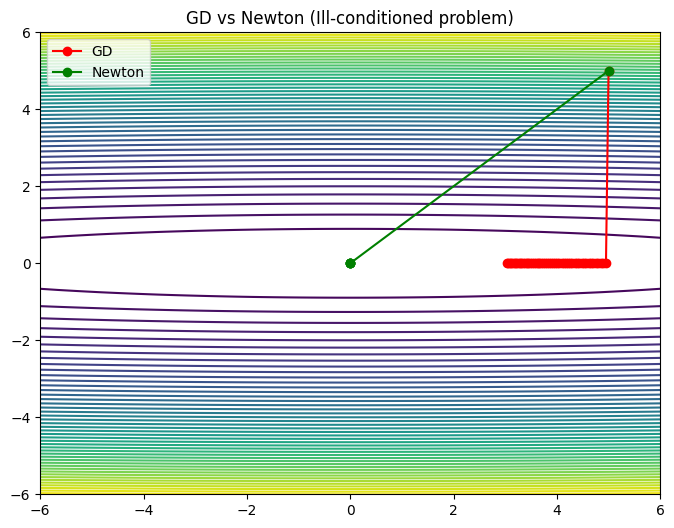

In [6]:
# contour plot
x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + 100 * Y**2)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=50)

# paths
plt.plot(gd_path[:,0], gd_path[:,1], 'r-o', label='GD')
plt.plot(newton_path[:,0], newton_path[:,1], 'g-o', label='Newton')

plt.legend()
plt.title("GD vs Newton (Ill-conditioned problem)")
plt.show()

In [9]:
def damped_newton(x0, iters=20, alpha=1.0, beta=0.5, c=1e-4):
    x = x0.copy()
    path = [x.copy()]
    
    for _ in range(iters):
        g = grad_f(x)
        H = hessian_f(x)
        
        # Newton direction
        d = np.linalg.solve(H, -g)
        
        # Backtracking line search
        t = alpha
        while f(x + t * d) > f(x) + c * t * np.dot(g, d):
            t *= beta
        
        x = x + t * d
        path.append(x.copy())
    
    return np.array(path)

In [10]:
def f_bad(x):
    return x[0]**4 + x[1]**2

def grad_bad(x):
    return np.array([4*x[0]**3, 2*x[1]])

def hessian_bad(x):
    return np.array([
        [12*x[0]**2, 0],
        [0, 2]
    ])

In [11]:
def newton_bad(x0, iters=10):
    x = x0.copy()
    path = [x.copy()]
    
    for _ in range(iters):
        g = grad_bad(x)
        H = hessian_bad(x)
        
        d = np.linalg.solve(H, -g)
        x = x + d
        path.append(x.copy())
    
    return np.array(path)

In [12]:
def damped_newton_bad(x0, iters=20, alpha=1.0, beta=0.5, c=1e-4):
    x = x0.copy()
    path = [x.copy()]
    
    for _ in range(iters):
        g = grad_bad(x)
        H = hessian_bad(x)
        
        d = np.linalg.solve(H, -g)
        
        t = alpha
        while f_bad(x + t * d) > f_bad(x) + c * t * np.dot(g, d):
            t *= beta
        
        x = x + t * d
        path.append(x.copy())
    
    return np.array(path)

In [13]:
x0 = np.array([2.0, 2.0])

newton_path = newton_bad(x0, iters=10)
damped_path = damped_newton_bad(x0, iters=20)

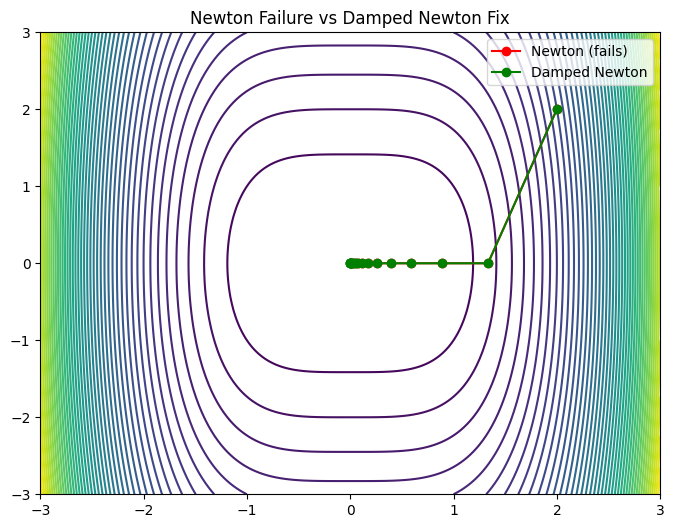

In [14]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = X**4 + Y**2

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=50)

plt.plot(newton_path[:,0], newton_path[:,1], 'r-o', label='Newton (fails)')
plt.plot(damped_path[:,0], damped_path[:,1], 'g-o', label='Damped Newton')

plt.legend()
plt.title("Newton Failure vs Damped Newton Fix")
plt.show()